In [1]:
import numpy as np
import pandas as pd

meta_data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\將mock拿掉重跑\GCN_metadata.csv")

In [2]:
print(meta_data.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACAACCGCTG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCACACACAGAG-1-1dpi_CoV2_HCR     Basal cells      1dpi   
2  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR      Tuft cells      1dpi   
4  AAACCCAGTTAGCGGA-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  label                label_source  
0                 0      0  high_confidence_uninfected  
1                 0      0  high_confidence_uninfected  
2                 2     -1                     unknown  
3                 0      0  high_confidence_uninfected  
4                 0      0  high_confidence_uninfected  


In [3]:
top_3000_gene = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\將mock拿掉重跑\GCN_genes.csv")

In [4]:
print(top_3000_gene.head())

          0
0     ISG15
1    TTLL10
2  C1QTNF12
3    TAS1R3
4    CFAP74


In [5]:
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad")

In [7]:
unknown_prediction = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\將mock拿掉重跑\其他機器學習模型\Logistic_unknown_prediction.csv")

In [8]:
print(unknown_prediction.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCATCGACGATT-1-1dpi_CoV2_HCR      Club cells      1dpi   
2  AAACGAACAGAGTCAG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACGAACAGCCCACA-1-1dpi_CoV2_HCR      Club cells      1dpi   
4  AAACGAAGTTCGATTG-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  label label_source  predict_label  infect_prob  
0                 2     -1      unknown              0     0.112997  
1                 1     -1      unknown              0     0.000013  
2                 1     -1      unknown              0     0.000087  
3                 1     -1      unknown              0     0.000032  
4                 0     -1      unknown              0     0.000047  


In [9]:
ct = pd.crosstab(
    unknown_prediction["ctype"],
    unknown_prediction["predict_label"]
)

print(ct)
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("df:", dof)
print("p-value:", p)


predict_label            0      1
ctype                            
BC/Club                875   1161
Basal cells           4097  13863
Ciliated cells        6403   5551
Club cells            6429   3429
Goblet cells            43     21
Ionocytes              321    133
Neuroendocrine cells   173     54
Tuft cells             145     71
Chi-square: 5818.569228372369
df: 7
p-value: 0.0


In [10]:
infection_rate = (
    unknown_prediction
    .groupby("ctype")["predict_label"]
    .mean()
    .sort_values(ascending=False)
)

print(infection_rate)

ctype
Basal cells             0.771882
BC/Club                 0.570236
Ciliated cells          0.464363
Club cells              0.347839
Tuft cells              0.328704
Goblet cells            0.328125
Ionocytes               0.292952
Neuroendocrine cells    0.237885
Name: predict_label, dtype: float64


In [38]:
# 比較GCN與Logistic針對unknown cell預測結果的不同

GCN_result = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\將mock拿掉重跑\GCN_unknown_prediction.csv")

Log_result = unknown_prediction.copy()

In [39]:
print(GCN_result.head())

print(Log_result.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCATCGACGATT-1-1dpi_CoV2_HCR      Club cells      1dpi   
2  AAACGAACAGAGTCAG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACGAACAGCCCACA-1-1dpi_CoV2_HCR      Club cells      1dpi   
4  AAACGAAGTTCGATTG-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  label label_source  predict_label  infect_prob  
0                 2     -1      unknown              0     0.000005  
1                 1     -1      unknown              0     0.000013  
2                 1     -1      unknown              0     0.000003  
3                 1     -1      unknown              0     0.004681  
4                 0     -1      unknown              0     0.000023  
                         Unnamed: 0           ctype Condition  \
0  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCATCGACGATT-1-1dpi_CoV2_HCR      Club cells      1d

In [40]:
print("Row 數量是否相同：",
      len(GCN_result) == len(Log_result))

print("Cell ID 是否完全相同且順序一致：",
      GCN_result["Unnamed: 0"].equals(
          Log_result["Unnamed: 0"]
      ))

print("ctype 是否完全一致：",
      GCN_result["ctype"].equals(
          Log_result["ctype"]
      ))

print("Condition 是否完全一致：",
      GCN_result["Condition"].equals(
          Log_result["Condition"]
      ))

print("Viral_transcript 是否完全一致：",
      GCN_result["Viral_transcript"].equals(
          Log_result["Viral_transcript"]
      ))

Row 數量是否相同： True
Cell ID 是否完全相同且順序一致： True
ctype 是否完全一致： True
Condition 是否完全一致： True
Viral_transcript 是否完全一致： True


In [41]:
# 合併比較

comparison_df = GCN_result[
    [
        "Unnamed: 0",
        "ctype",
        "Condition",
        "Viral_transcript"
    ]
].copy()

comparison_df["GCN_label"] = GCN_result["predict_label"]
comparison_df["GCN_prob"] = GCN_result["infect_prob"]

comparison_df["Logistic_label"] = Log_result["predict_label"]
comparison_df["Logistic_prob"] = Log_result["infect_prob"]

print(comparison_df.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCATCGACGATT-1-1dpi_CoV2_HCR      Club cells      1dpi   
2  AAACGAACAGAGTCAG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACGAACAGCCCACA-1-1dpi_CoV2_HCR      Club cells      1dpi   
4  AAACGAAGTTCGATTG-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  GCN_label  GCN_prob  Logistic_label  Logistic_prob  
0                 2          0  0.000005               0       0.112997  
1                 1          0  0.000013               0       0.000013  
2                 1          0  0.000003               0       0.000087  
3                 1          0  0.004681               0       0.000032  
4                 0          0  0.000023               0       0.000047  


In [44]:
# GCN 以及 Logistic 的預測結果列聯表
prediction_crosstab = pd.crosstab(
    comparison_df["GCN_label"],
    comparison_df["Logistic_label"],
    margins=True
)

print(prediction_crosstab)

Logistic_label      0      1    All
GCN_label                          
0               16523   6423  22946
1                1963  17860  19823
All             18486  24283  42769


In [46]:
prediction_crosstab_pct = pd.crosstab(
    comparison_df["GCN_label"],
    comparison_df["Logistic_label"],
    normalize="index"
) * 100

print(prediction_crosstab_pct.round(2))

Logistic_label      0      1
GCN_label                   
0               72.01  27.99
1                9.90  90.10


In [73]:
comparison_df["prediction_group"] = np.select(
    [
        (comparison_df["GCN_label"] == 0) &
        (comparison_df["Logistic_label"] == 0),

        (comparison_df["GCN_label"] == 0) &
        (comparison_df["Logistic_label"] == 1),

        (comparison_df["GCN_label"] == 1) &
        (comparison_df["Logistic_label"] == 0),

        (comparison_df["GCN_label"] == 1) &
        (comparison_df["Logistic_label"] == 1)
    ],
    [
        "Both 0",
        "GCN 0 / Logistic 1",
        "GCN 1 / Logistic 0",
        "Both 1"
    ],
    default="Other"
)

print(comparison_df["prediction_group"].value_counts())

prediction_group
Both 1                17860
Both 0                16523
GCN 0 / Logistic 1     6423
GCN 1 / Logistic 0     1963
Name: count, dtype: int64


In [75]:
print(
    comparison_df
    .groupby("prediction_group")
    ["Viral_transcript"]
    .agg(["count", "mean", "median", "std"])
)

                    count       mean  median         std
prediction_group                                        
Both 0              16523   2.337530     1.0    5.344225
Both 1              17860  21.404815     3.0  190.347488
GCN 0 / Logistic 1   6423   4.771913     3.0   13.212732
GCN 1 / Logistic 0   1963   1.815079     1.0    4.377910


<Figure size 900x600 with 0 Axes>

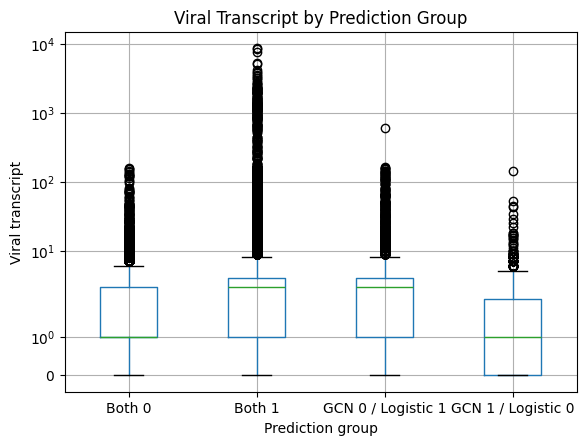

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

comparison_df.boxplot(
    column="Viral_transcript",
    by="prediction_group"
)

plt.yscale("symlog")

plt.xlabel("Prediction group")
plt.ylabel("Viral transcript")
plt.title("Viral Transcript by Prediction Group")

plt.suptitle("")
plt.show()

In [76]:
ctype_summary = (
    comparison_df
    .groupby("ctype")
    .agg(
        n_cells=("Unnamed: 0", "size"),
        GCN_infected=("GCN_label", "sum"),
        Logistic_infected=("Logistic_label", "sum"),
        mean_GCN_prob=("GCN_prob", "mean"),
        mean_Logistic_prob=("Logistic_prob", "mean"),
        mean_Viral_transcript=("Viral_transcript", "mean")
    )
)

print(ctype_summary)

                      n_cells  GCN_infected  Logistic_infected  mean_GCN_prob  \
ctype                                                                           
BC/Club                  2036          1160               1161       0.573961   
Basal cells             17960         10137              13863       0.553856   
Ciliated cells          11954          5764               5551       0.478711   
Club cells               9858          2707               3429       0.284159   
Goblet cells               64            17                 21       0.244307   
Ionocytes                 454            27                133       0.120365   
Neuroendocrine cells      227             2                 54       0.038226   
Tuft cells                216             9                 71       0.081932   

                      mean_Logistic_prob  mean_Viral_transcript  
ctype                                                            
BC/Club                         0.565337               5.

In [77]:
ctype_summary["GCN_infection_rate"] = (
    ctype_summary["GCN_infected"] /
    ctype_summary["n_cells"]
)

ctype_summary["Logistic_infection_rate"] = (
    ctype_summary["Logistic_infected"] /
    ctype_summary["n_cells"]
)

In [78]:
condition_summary = (
    comparison_df
    .groupby("Condition")
    .agg(
        n_cells=("Unnamed: 0", "size"),
        mean_GCN_prob=("GCN_prob", "mean"),
        mean_Logistic_prob=("Logistic_prob", "mean"),
        mean_Viral_transcript=("Viral_transcript", "mean")
    )
)

print(condition_summary)

           n_cells  mean_GCN_prob  mean_Logistic_prob  mean_Viral_transcript
Condition                                                                   
1dpi          3046       0.022462            0.022213               3.057124
2dpi         13145       0.132616            0.213763               8.195968
3dpi         26578       0.674414            0.796019              12.720220


In [56]:
# GCN判斷細胞是否感染的機率與病毒轉錄體的多寡之關係
comparison_df.loc[:,["Viral_transcript" , "GCN_prob"]]

,Viral_transcript,GCN_prob
0,2,0.000005
1,1,0.000013
2,1,0.000003
3,1,0.004681
4,0,0.000023
...,...,...
42764,4,0.013681
42765,3,0.949422
42766,6,0.344382
42767,3,0.999234


In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# 建立 viral transcript 分組
comparison_df["Viral_group"] = pd.cut(
    comparison_df["Viral_transcript"],
    bins=[-1, 0, 1, 2, 3, 4, 5, 10, 20, float("inf")],
    labels=["0", "1", "2", "3", "4", "5", "6–10", "11–20", ">20"]
)

# 計算每組平均 GCN probability
grouped = (
    comparison_df
    .groupby("Viral_group", observed=True)
    .agg(
        n=("GCN_prob", "size"),
        mean_GCN_prob=("GCN_prob", "mean"),
        sd_GCN_prob=("GCN_prob", "std")
    )
    .reset_index()
)

# Standard error
grouped["SE"] = grouped["sd_GCN_prob"] / np.sqrt(grouped["n"])

# 95% CI
grouped["CI_lower"] = (
    grouped["mean_GCN_prob"] - 1.96 * grouped["SE"]
)

grouped["CI_upper"] = (
    grouped["mean_GCN_prob"] + 1.96 * grouped["SE"]
)

print(grouped)

  Viral_group      n  mean_GCN_prob  sd_GCN_prob        SE  CI_lower  CI_upper
0           0   6334       0.361588     0.411630  0.005172  0.351450  0.371725
1           1  10473       0.380961     0.418167  0.004086  0.372952  0.388970
2           2   8553       0.469677     0.424866  0.004594  0.460673  0.478681
3           3   6015       0.513757     0.420408  0.005421  0.503132  0.524381
4           4   3760       0.518734     0.425020  0.006931  0.505149  0.532320
5           5   2156       0.519721     0.418660  0.009016  0.502049  0.537393
6        6–10   3026       0.524041     0.423026  0.007690  0.508969  0.539114
7       11–20    911       0.511691     0.433799  0.014372  0.483522  0.539861
8         >20   1541       0.795514     0.353627  0.009008  0.777858  0.813171


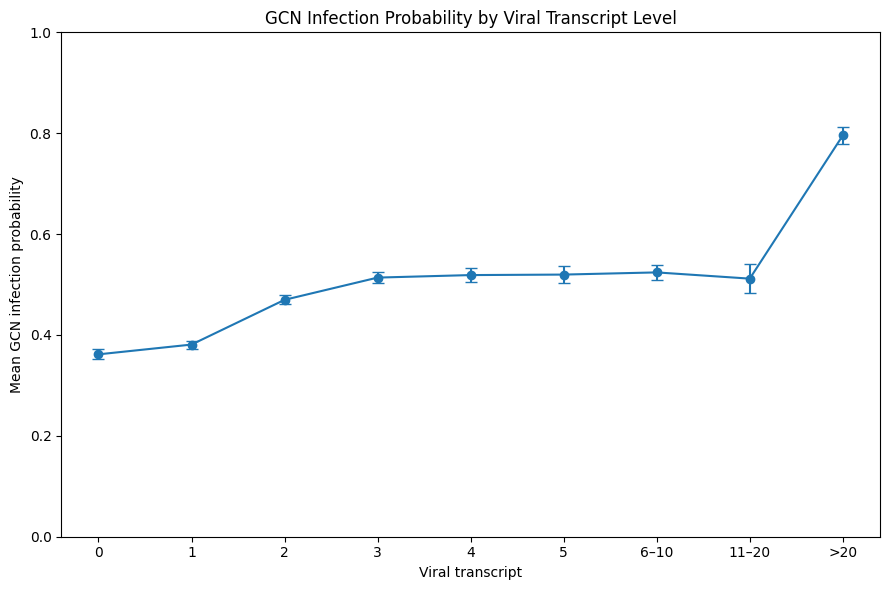

In [64]:
plt.figure(figsize=(9, 6))

x = np.arange(len(grouped))

plt.errorbar(
    x,
    grouped["mean_GCN_prob"],
    yerr=[
        grouped["mean_GCN_prob"] - grouped["CI_lower"],
        grouped["CI_upper"] - grouped["mean_GCN_prob"]
    ],
    marker="o",
    capsize=4
)

plt.xticks(
    x,
    grouped["Viral_group"]
)

plt.xlabel("Viral transcript")
plt.ylabel("Mean GCN infection probability")
plt.title("GCN Infection Probability by Viral Transcript Level")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [66]:
# Logistic判斷細胞是否感染的機率與病毒轉錄體的多寡之關係
comparison_df.loc[:,["Viral_transcript" , "Logistic_prob"]]

,Viral_transcript,Logistic_prob
0,2,0.112997
1,1,0.000013
2,1,0.000087
3,1,0.000032
4,0,0.000047
...,...,...
42764,4,0.993029
42765,3,0.964425
42766,6,0.999840
42767,3,0.999962


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 建立 viral transcript 分組
comparison_df["Viral_group"] = pd.cut(
    comparison_df["Viral_transcript"],
    bins=[-1, 0, 1, 2, 3, 4, 5, 10, 20, float("inf")],
    labels=["0", "1", "2", "3", "4", "5", "6–10", "11–20", ">20"]
)

# 計算每組平均 Logistic probability
grouped = (
    comparison_df
    .groupby("Viral_group", observed=True)
    .agg(
        n=("Logistic_prob", "size"),
        mean_Logistic_prob=("Logistic_prob", "mean"),
        sd_Logistic_prob=("Logistic_prob", "std")
    )
    .reset_index()
)

# Standard error
grouped["SE"] = (
    grouped["sd_Logistic_prob"] /
    np.sqrt(grouped["n"])
)

# 95% CI
grouped["CI_lower"] = (
    grouped["mean_Logistic_prob"] -
    1.96 * grouped["SE"]
)

grouped["CI_upper"] = (
    grouped["mean_Logistic_prob"] +
    1.96 * grouped["SE"]
)

print(grouped)

  Viral_group      n  mean_Logistic_prob  sd_Logistic_prob        SE  \
0           0   6334            0.297370          0.383458  0.004818   
1           1  10473            0.465616          0.438763  0.004287   
2           2   8553            0.594422          0.424752  0.004593   
3           3   6015            0.661958          0.405461  0.005228   
4           4   3760            0.674871          0.401356  0.006545   
5           5   2156            0.695888          0.393783  0.008481   
6        6–10   3026            0.696595          0.390326  0.007096   
7       11–20    911            0.716504          0.384138  0.012727   
8         >20   1541            0.914968          0.234292  0.005968   

   CI_lower  CI_upper  
0  0.287927  0.306814  
1  0.457213  0.474020  
2  0.585420  0.603424  
3  0.651711  0.672205  
4  0.662042  0.687700  
5  0.679265  0.712510  
6  0.682688  0.710503  
7  0.691559  0.741449  
8  0.903270  0.926666  


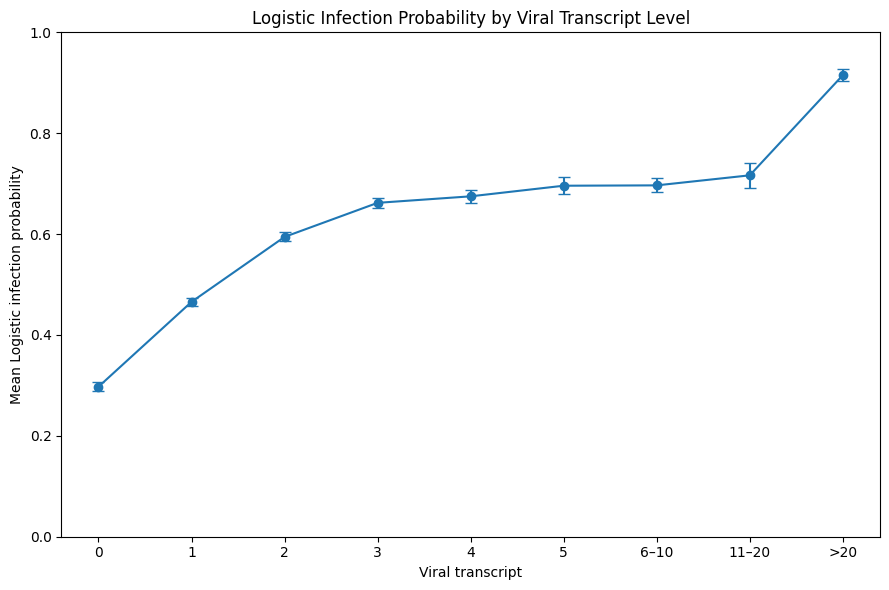

In [69]:
plt.figure(figsize=(9, 6))

x = np.arange(len(grouped))

plt.errorbar(
    x,
    grouped["mean_Logistic_prob"],
    yerr=[
        grouped["mean_Logistic_prob"] - grouped["CI_lower"],
        grouped["CI_upper"] - grouped["mean_Logistic_prob"]
    ],
    marker="o",
    capsize=4
)

plt.xticks(
    x,
    grouped["Viral_group"]
)

plt.xlabel("Viral transcript")
plt.ylabel("Mean Logistic infection probability")
plt.title("Logistic Infection Probability by Viral Transcript Level")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()